In [ ]:
# analyzing asd reflectances summer (051725) vs. winter (112125)

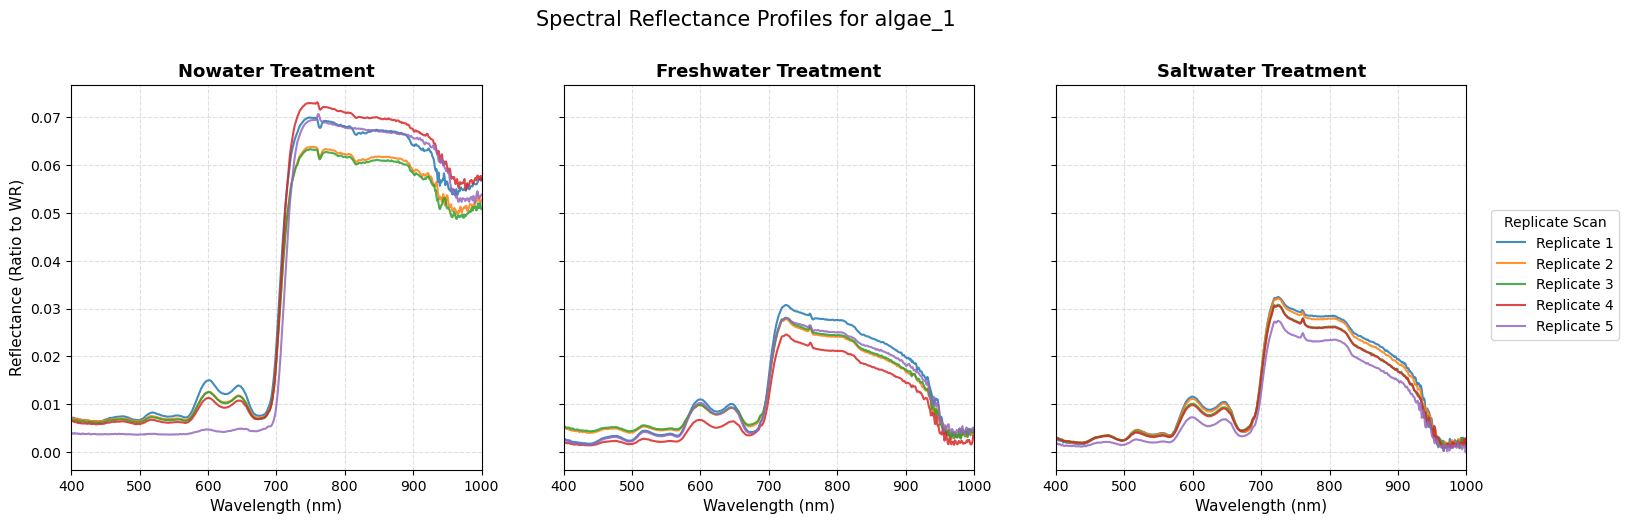

In [5]:
import os
import matplotlib.pyplot as plt
import pandas as pd

# 1. Load the exported tidy dataset
csv_path = r"C:\Users\kimmi\OneDrive - Chapman University\SEACR\mkim_seacr_algaedata\specsign_data\250517_algae_ASDrefl_master.xlsx"
tidy_df = pd.read_excel(csv_path)

# 2. Filter strictly for algae_1
algae_1_df = tidy_df[tidy_df["specimen"] == "algae_1"]

# 3. Setup subplots for the 3 treatments
treatments = ["nowater", "freshwater", "saltwater"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True, sharex=True)

# Define distinct line colors for replicates 1 through 5
rep_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

for ax, treat in zip(axes, treatments):
    subset = algae_1_df[algae_1_df["treatment"] == treat]

    # Plot each replicate scan individually
    for rep in sorted(subset["replicate"].unique()):
        rep_data = subset[subset["replicate"] == rep]
        ax.plot(
            rep_data["wavelength_nm"],
            rep_data["reflectance"],
            label=f"Replicate {rep}",
            color=rep_colors[(rep - 1) % len(rep_colors)],
            alpha=0.85,
            linewidth=1.5,
        )

    ax.set_title(
        f"{treat.capitalize()} Treatment", fontsize=13, fontweight="bold"
    )
    ax.set_xlabel("Wavelength (nm)", fontsize=11)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.set_xlim(400, 1000)

axes[0].set_ylabel("Reflectance (Ratio to WR)", fontsize=11)

# Put a single, unified legend on the right
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.91, 0.5),
    title="Replicate Scan",
)

plt.suptitle("Spectral Reflectance Profiles for algae_1", fontsize=15, y=1.03)
plt.subplots_adjust(right=0.9)
plt.show()